<a href="https://colab.research.google.com/github/thisismebipin/Customer-Churn-Analysis/blob/main/Predictive_Modeling/Predictive_Modeling_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1. Setup and Data Loading
In this step, we import the necessary Python libraries for data manipulation and deep learning. We then load the pre-processed dataset to understand its structure and prepare it for the Neural Network.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
url="https://raw.githubusercontent.com/thisismebipin/Customer-Churn-Analysis/main/Data_Preparation/Preprocessed_Data/Processed_data.csv"
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load the dataset
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Processed_data.csv not found. Please make sure the file is uploaded.")

# Display first few rows
# 显示前几行
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Check data types and for any missing values
# 检查数据类型和缺失值
print("\nData Info:")
print(df.info())

# Check the distribution of the target variable 'Churn'
# 检查目标变量 'Churn' 的分布
if 'Churn' in df.columns:
    print("\nChurn Distribution:")
    print(df['Churn'].value_counts())
else:
    print("\nWarning: 'Churn' column not found!")

Dataset loaded successfully.

First 5 rows of the dataset:


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,Churn,InternetService_Fiber optic,Contract_One year,Contract_Two year
0,0,0,0,1,0,0,25,1,False,False,False
1,1,0,0,41,1,0,25,0,False,True,False
2,0,0,1,52,1,0,19,0,False,False,False
3,0,0,0,1,1,0,76,1,False,True,False
4,1,0,0,67,1,0,51,0,True,False,False



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       7043 non-null   int64
 1   SeniorCitizen                7043 non-null   int64
 2   Dependents                   7043 non-null   int64
 3   tenure                       7043 non-null   int64
 4   PhoneService                 7043 non-null   int64
 5   MultipleLines                7043 non-null   int64
 6   MonthlyCharges               7043 non-null   int64
 7   Churn                        7043 non-null   int64
 8   InternetService_Fiber optic  7043 non-null   bool 
 9   Contract_One year            7043 non-null   bool 
 10  Contract_Two year            7043 non-null   bool 
dtypes: bool(3), int64(8)
memory usage: 461.0 KB
None

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


# Step 2. Data Preprocessing
In this step, we prepare the data for the ANN model.
1.  **Feature Separation**: Separate the features (X) from the target variable (y, 'Churn').
2.  **Train-Test Split**: Split the data into training (80%) and testing (20%) sets to evaluate performance on unseen data.
3.  **Feature Scaling**: Apply `StandardScaler` to standardize the features. This is crucial for Neural Networks because it ensures all input features contribute equally and helps the gradient descent algorithm converge faster.


In [3]:
# 1. Separate Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convert any boolean columns to integers for consistency
X = X.astype(int)

# 2. Split the data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling (Standardization)
scaler = StandardScaler()

# Fit on training set only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check the shapes to ensure everything looks correct
print("Training features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Display the first row of scaled data to verify
print("\nFirst row of scaled training data:")
print(X_train_scaled[0])

Training features shape: (5634, 10)
Testing features shape: (1409, 10)
Training target shape: (5634,)
Testing target shape: (1409,)

First row of scaled training data:
[ 0.99046083 -0.44005007  1.53739458  1.28404639  0.32891113 -0.86052337
  1.46748623 -0.88705673  1.9101086  -0.55835281]


# Step 3. Define ANN Architecture
In this step, we define the architecture of the Artificial Neural Network (ANN).
We utilize a **Sequential** model from Keras with the following layers:
* **Input Layer**: Implicitly defined by the input shape of (10,), matching our 10 features.
* **Hidden Layer 1**: 16 neurons with `relu` activation function to capture non-linear relationships.
* **Hidden Layer 2**: 8 neurons with `relu` activation function for further feature processing.
* **Output Layer**: 1 neuron with `sigmoid` activation function. This is standard for binary classification as it outputs a probability between 0 and 1 (Churn vs No Churn).

We then display the model summary to verify the architecture and the number of trainable parameters.


In [4]:
# Define the ANN model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10,)), # Hidden layer 1 (receives 10 inputs)
    layers.Dense(8, activation='relu'),                     # Hidden layer 2
    layers.Dense(1, activation='sigmoid')                   # Output layer (Binary classification)
])

# Compile the model
# We use 'adam' optimizer and 'binary_crossentropy' loss for binary classification
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
print("ANN Model Architecture:")
model.summary()

ANN Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4. Train ANN Model
In this step, we train the ANN model using the `fit` method.
* **Epochs**: We set it to 50, meaning the model will see the entire dataset 50 times.
* **Batch Size**: Set to 32, meaning the weights are updated after every 32 samples.
* **Validation Split**: We use 20% of the training data as a validation set to monitor for overfitting during training.

After training, we plot the **Accuracy** and **Loss** curves to visualize the model's learning progress.


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5476 - loss: 0.7028 - val_accuracy: 0.7471 - val_loss: 0.5117
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7331 - loss: 0.5219 - val_accuracy: 0.7640 - val_loss: 0.4758
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7615 - loss: 0.4927 - val_accuracy: 0.7764 - val_loss: 0.4609
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7650 - loss: 0.4782 - val_accuracy: 0.7764 - val_loss: 0.4533
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7679 - loss: 0.4710 - val_accuracy: 0.7844 - val_loss: 0.4485
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7719 - loss: 0.4659 - val_accuracy: 0.7844 - val_loss: 0.4449
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7742 - loss: 0.4620 - val_accuracy: 0.7897 - val_loss: 0.4424
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7761 - loss: 0.4587 - val_accuracy: 0.

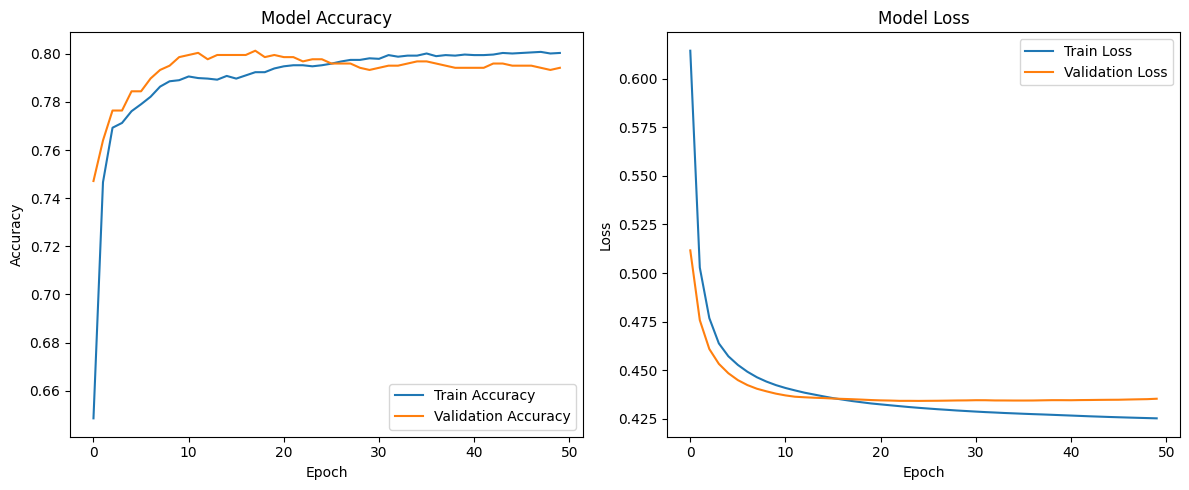

In [5]:
# Train the model
history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2, # Use 20% of training data for validation / 使用 20% 的训练数据进行验证
                    verbose=1)

# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 5. Evaluate and Predict
In this step, we evaluate the trained model on the test dataset.
1.  **Evaluate**: Calculate the final loss and accuracy on the test set.
2.  **Predict**: Generate churn probabilities for the test set.
3.  **Thresholding**: Convert probabilities to binary class labels (0 or 1) using a threshold of 0.5.
4.  **Confusion Matrix**: Visualize True Positives, True Negatives, False Positives, and False Negatives.
5.  **Classification Report**: Review Precision, Recall, and F1-Score for each class.


Test Accuracy: 75.66%
Test Loss: 0.4739
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1042
           1       0.54      0.43      0.48       367

    accuracy                           0.76      1409
   macro avg       0.68      0.65      0.66      1409
weighted avg       0.74      0.76      0.75      1409



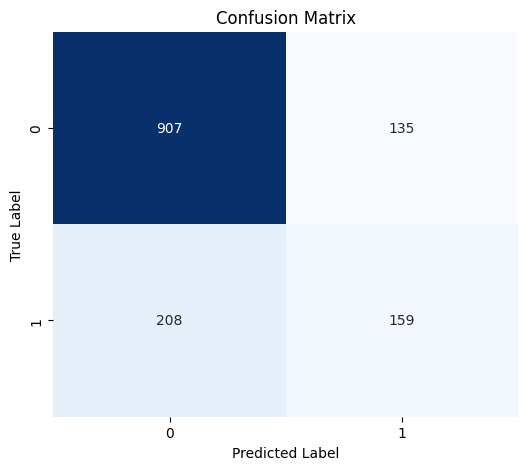

In [6]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2. Make Predictions
y_pred_probs = model.predict(X_test_scaled)
# Convert probabilities to binary (0 or 1) based on 0.5 threshold
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Confusion Matrix and Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


# Step 5.5. Improving Model Recall (Class Weights)
**Recall for Churn (Class 1)**: 0.45 - This means the model correctly identified 45% of the customers who actually churned. It missed about 55% (False Negatives). This is common in imbalanced datasets (where there are more non-churners than churners).

Since the Recall for the 'Churn' class (Class 1) was low, we will retrain the model using **Class Weights**.
This technique assigns a higher penalty to the model for misclassifying the minority class (Churners), forcing it to pay more attention to them.

1.  **Calculate Class Weights**: Compute weights inversely proportional to class frequencies.
2.  **Re-build Model**: We must re-initialize the model to reset the parameters.
3.  **Train with Weights**: Pass the `class_weight` parameter to the `fit()` function.


Computed Class Weights: {0: np.float64(0.6817521781219749), 1: np.float64(1.8754993342210386)}

Starting training with Class Weights...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5941 - loss: 0.7066 - val_accuracy: 0.6770 - val_loss: 0.5955
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6878 - loss: 0.6080 - val_accuracy: 0.7019 - val_loss: 0.5510
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7114 - loss: 0.5603 - val_accuracy: 0.7169 - val_loss: 0.5320
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7142 - loss: 0.5409 - val_accuracy: 0.7294 - val_loss: 0.5233
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7214 - loss: 0.5338 - val_accuracy: 0.7311 - val_loss: 0.5202
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7261 - loss: 0.5300 - val_accuracy: 0.7347 - val_loss: 0.5184
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7283 - loss: 0.5276 - val_accuracy: 0.7356 - val_loss: 0.5162
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7298 - loss: 0.5258 - val_accuracy: 0.7374 - val_

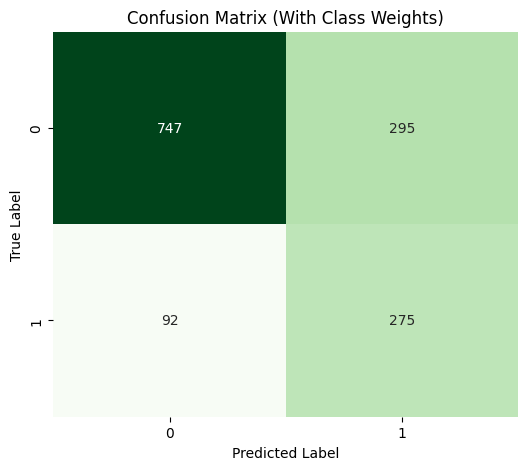

In [7]:
from sklearn.utils import class_weight

# 1. Calculate Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
# Convert to dictionary format required by Keras
class_weight_dict = dict(enumerate(class_weights))
print("Computed Class Weights:", class_weight_dict)
# Class 1 should have a higher weight than Class 0

# 2. Re-build the Model (Resetting weights)
model_improved = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_improved.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Train with Class Weights
print("\nStarting training with Class Weights...")
history_improved = model_improved.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict, # <--- Key change here
    verbose=1
)

# 4. Evaluate the Improved Model
print("\nEvaluating Improved Model...")
y_pred_improved_probs = model_improved.predict(X_test_scaled)
y_pred_improved = (y_pred_improved_probs > 0.5).astype(int)

print("\nClassification Report (Improved Model):")
print(classification_report(y_test, y_pred_improved))

# Show Confusion Matrix for comparison
cm_improved = confusion_matrix(y_test, y_pred_improved)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (With Class Weights)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Improved Model ROC-AUC Score: 0.795


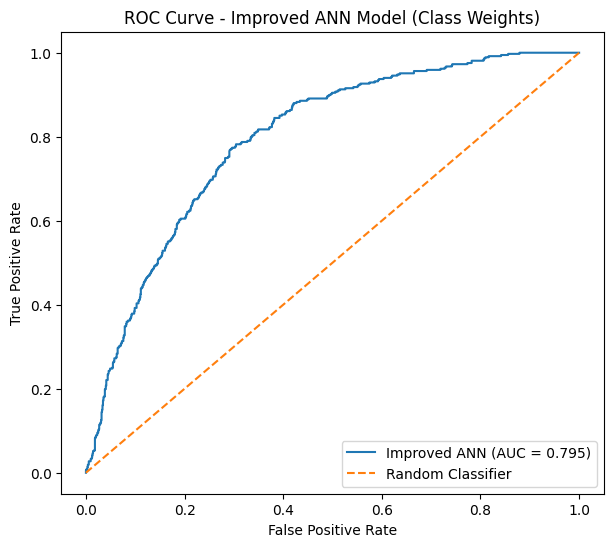

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_improved_probs)
print(f"Improved Model ROC-AUC Score: {roc_auc:.3f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_improved_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Improved ANN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Improved ANN Model (Class Weights)")
plt.legend(loc="lower right")
plt.show()

# Step 6. Save the Improved Model

In [9]:
# Save the improved model to H5 format
model_improved.save('Churn_Prediction_Model.h5')

print("Improved model saved as 'Churn_Prediction_Model.h5'.")
print("Please check the 'Files' tab in Colab to download it.")

Improved model saved as 'Churn_Prediction_Model.h5'.
Please check the 'Files' tab in Colab to download it.
